# Decision Tree Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/02-regression/05_decision_tree_regression.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Decision trees for regression (not just classification)
- Tree splitting strategy (greedy algorithm)
- Controlling tree depth (prevent overfitting)
- Feature importance from trees

## Why This Matters

Decision trees don't fit curves—they fit step functions.

**Example:** Predicting house price
```
If size < 1000 sq-ft:   Price = $150k
Elif size < 2000 sq-ft: Price = $300k
Else:                   Price = $500k
```

**Pros:**
- No need to scale data
- Handles non-linear patterns
- Interpretable (see the rules)

**Cons:**
- Prone to overfitting
- Step-like predictions (not smooth)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

np.random.seed(42)
print("Decision Tree Regression: Rules-Based Predictions")

Decision Tree Regression: Rules-Based Predictions


---
## 1. Create Non-Linear Data

House Size vs Price:
             Size       Price
count  100.000000  100.000000
mean    47.018074  177.630747
std     29.748941   87.735273
min      0.552212   53.714131
25%     19.320076   90.698391
50%     46.414245  171.365114
75%     73.020312  258.634616
max     98.688694  341.286502


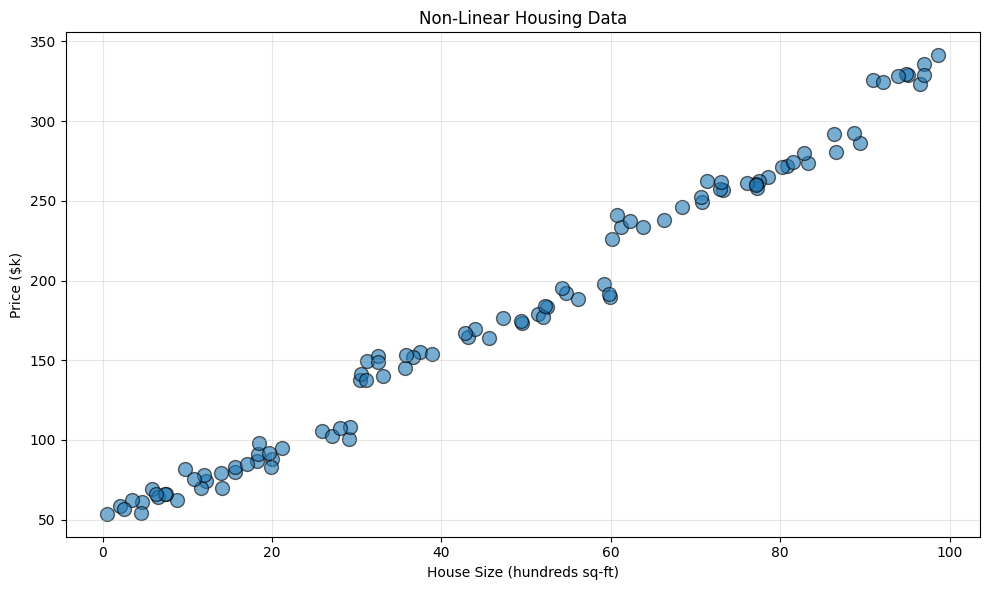

Notice: Data has natural groupings (like price jumps)


In [2]:
# House size vs price (non-linear)
X = np.random.rand(100, 1) * 100  # Size: 0-100 hundred sq-ft

# Non-linear relationship with steps
y = 50 + X.flatten() * 2 + (X.flatten() // 30) * 30 + np.random.normal(0, 5, len(X))

df = pd.DataFrame({'Size': X.flatten(), 'Price': y})
print("House Size vs Price:")
print(df.describe())

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=100, alpha=0.6, edgecolors='black')
plt.xlabel('House Size (hundreds sq-ft)')
plt.ylabel('Price ($k)')
plt.title('Non-Linear Housing Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: Data has natural groupings (like price jumps)")

---
## 2. Train Decision Tree

In [3]:
# Unlimited tree (will overfit)
dt_unlimited = DecisionTreeRegressor(random_state=42)
dt_unlimited.fit(X, y)

# Limited tree (depth=5)
dt_limited = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_limited.fit(X, y)

# Predictions
y_pred_unlimited = dt_unlimited.predict(X)
y_pred_limited = dt_limited.predict(X)

# Metrics
r2_unlimited = r2_score(y, y_pred_unlimited)
r2_limited = r2_score(y, y_pred_limited)

print("Unlimited Tree:")
print(f"  Depth: {dt_unlimited.get_depth()}")
print(f"  Leaves: {dt_unlimited.get_n_leaves()}")
print(f"  R² (train): {r2_unlimited:.4f}")

print("\nLimited Tree (max_depth=5):")
print(f"  Depth: {dt_limited.get_depth()}")
print(f"  Leaves: {dt_limited.get_n_leaves()}")
print(f"  R² (train): {r2_limited:.4f}")

print("\n✅ Limited tree is simpler but still fits!")

Unlimited Tree:
  Depth: 13
  Leaves: 100
  R² (train): 1.0000

Limited Tree (max_depth=5):
  Depth: 5
  Leaves: 30
  R² (train): 0.9990

✅ Limited tree is simpler but still fits!


---
## 3. Visualize Tree Structure

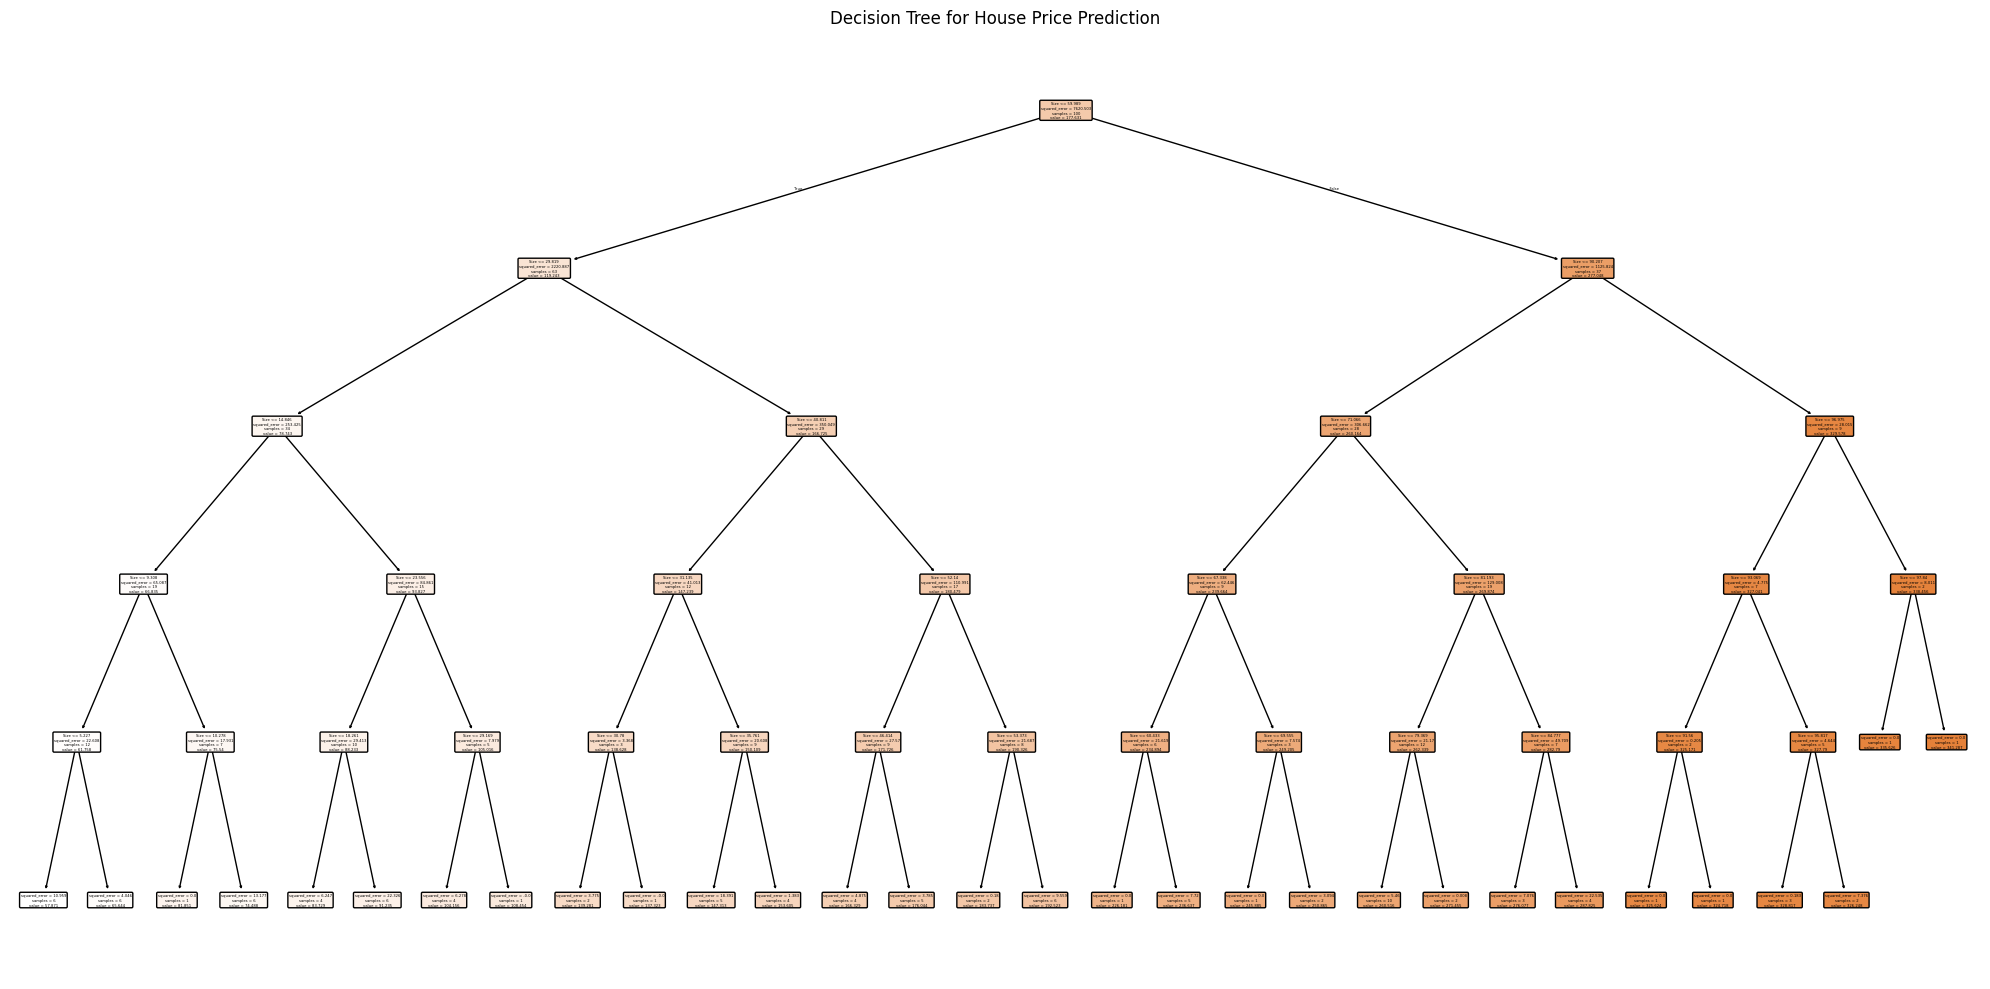

Reading the tree:
  - Each box is a decision node
  - 'mse': Mean squared error at that node
  - 'samples': Number of data points
  - 'value': Average prediction
  - Leaf nodes (color): Final predictions


In [4]:
# Visualize limited tree
plt.figure(figsize=(20, 10))
plot_tree(dt_limited, feature_names=['Size'], filled=True, rounded=True)
plt.title('Decision Tree for House Price Prediction')
plt.tight_layout()
plt.show()

print("Reading the tree:")
print("  - Each box is a decision node")
print("  - 'mse': Mean squared error at that node")
print("  - 'samples': Number of data points")
print("  - 'value': Average prediction")
print("  - Leaf nodes (color): Final predictions")

---
## 4. Step Function Predictions

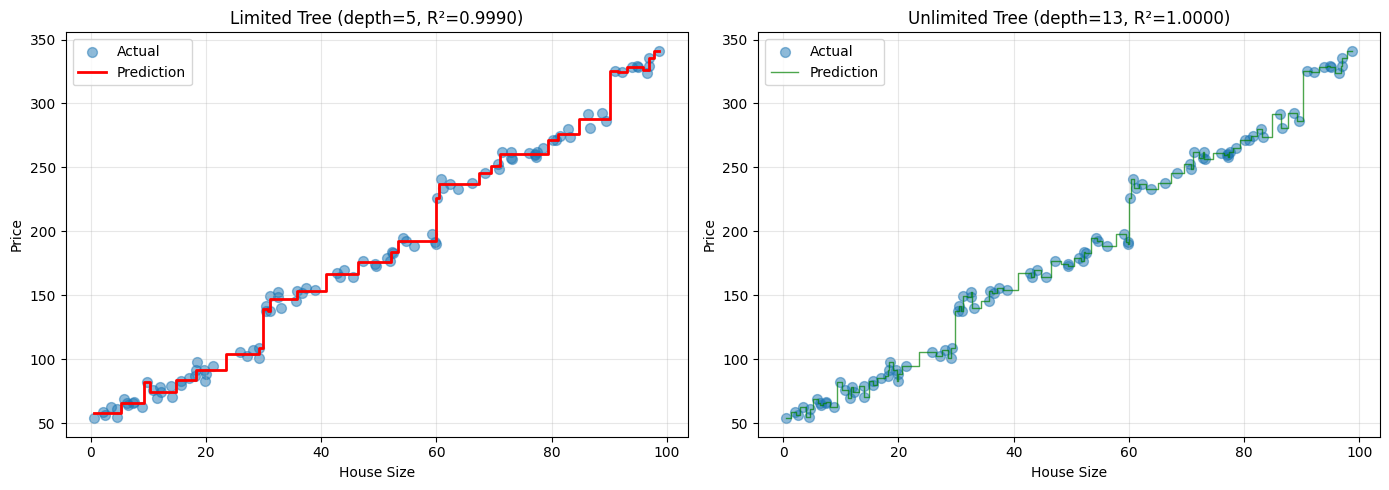

Step Function: Predictions are constant within regions
Unlimited tree: Overfits (too many steps)
Limited tree: More generalizable


In [5]:
# Sort for plotting
sort_idx = np.argsort(X.flatten())
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

# Get predictions on sorted data
y_pred_limited_sorted = dt_limited.predict(X_sorted)
y_pred_unlimited_sorted = dt_unlimited.predict(X_sorted)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Limited depth
axes[0].scatter(X, y, s=50, alpha=0.5, label='Actual')
axes[0].step(X_sorted.flatten(), y_pred_limited_sorted, 'r-', linewidth=2, label='Prediction', where='mid')
axes[0].set_title(f'Limited Tree (depth=5, R²={r2_limited:.4f})')
axes[0].set_xlabel('House Size')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Unlimited (will look very jagged)
axes[1].scatter(X, y, s=50, alpha=0.5, label='Actual')
axes[1].step(X_sorted.flatten(), y_pred_unlimited_sorted, 'g-', linewidth=1, label='Prediction', where='mid', alpha=0.7)
axes[1].set_title(f'Unlimited Tree (depth={dt_unlimited.get_depth()}, R²={r2_unlimited:.4f})')
axes[1].set_xlabel('House Size')
axes[1].set_ylabel('Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Step Function: Predictions are constant within regions")
print("Unlimited tree: Overfits (too many steps)")
print("Limited tree: More generalizable")

---
## 5. Overfitting: Train vs Test

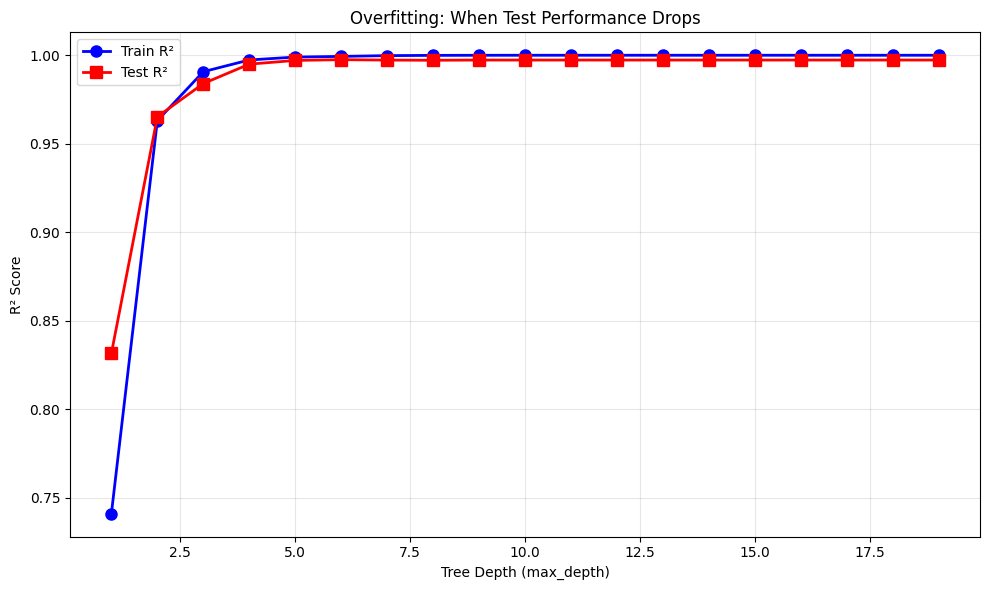

Best Max Depth: 6

⚠️ Beyond depth=6: Test performance decreases
   That's overfitting!


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Test different depths
depths = range(1, 20)
train_r2s = []
test_r2s = []

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_r2 = dt.score(X_train, y_train)
    test_r2 = dt.score(X_test, y_test)
    
    train_r2s.append(train_r2)
    test_r2s.append(test_r2)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(depths, train_r2s, 'b-o', linewidth=2, markersize=8, label='Train R²')
plt.plot(depths, test_r2s, 'r-s', linewidth=2, markersize=8, label='Test R²')
plt.xlabel('Tree Depth (max_depth)')
plt.ylabel('R² Score')
plt.title('Overfitting: When Test Performance Drops')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(test_r2s)]
print(f"Best Max Depth: {best_depth}")
print(f"\n⚠️ Beyond depth={best_depth}: Test performance decreases")
print("   That's overfitting!")

---
## 6. Feature Importance

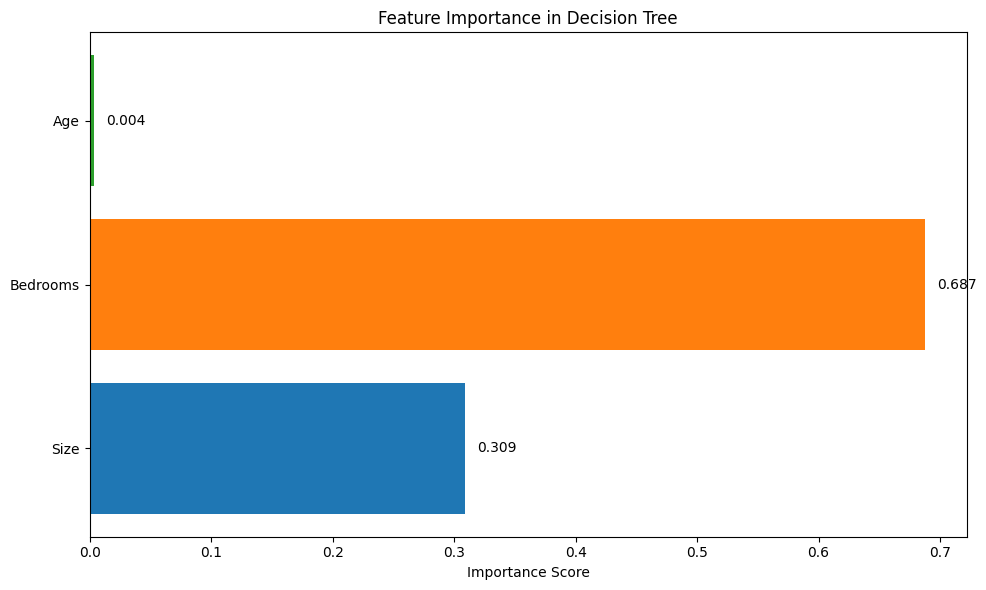

Feature Importance:
  Size: 0.3090
  Bedrooms: 0.6874
  Age: 0.0036


In [7]:
# Create multi-feature dataset
X_multi = np.random.rand(100, 3)
X_multi[:, 0] *= 100  # Size (0-100)
X_multi[:, 1] *= 5    # Bedrooms (0-5)
X_multi[:, 2] *= 50   # Age (0-50)

# Size is most important
y_multi = 50 + 2 * X_multi[:, 0] + 50 * X_multi[:, 1] + np.random.normal(0, 5, 100)

# Train
dt_multi = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_multi.fit(X_multi, y_multi)

# Get importance
importance = dt_multi.feature_importances_
feature_names = ['Size', 'Bedrooms', 'Age']

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xlabel('Importance Score')
plt.title('Feature Importance in Decision Tree')
for i, v in enumerate(importance):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

print("Feature Importance:")
for name, imp in zip(feature_names, importance):
    print(f"  {name}: {imp:.4f}")

---
## 7. When to Use Decision Trees

In [9]:
print("✅ USE Decision Tree Regression when:")
print("  - Data has non-linear, multi-level patterns")
print("  - You need interpretable predictions")
print("  - You want feature importance")
print("  - Data has mixed types (no scaling needed)")
print("\n❌ DON'T USE when:")
print("  - Data is mostly linear (overkill)")
print("  - You need smooth predictions")
print("  - Dataset is tiny (risk overfitting)")
print("\n💡 Tips:")
print("  - Always limit max_depth (prevent overfitting)")
print("  - Start with depth=5, tune up if needed")
print("  - Use Random Forest for better performance")

✅ USE Decision Tree Regression when:
  - Data has non-linear, multi-level patterns
  - You need interpretable predictions
  - You want feature importance
  - Data has mixed types (no scaling needed)

❌ DON'T USE when:
  - Data is mostly linear (overkill)
  - You need smooth predictions
  - Dataset is tiny (risk overfitting)

💡 Tips:
  - Always limit max_depth (prevent overfitting)
  - Start with depth=5, tune up if needed
  - Use Random Forest for better performance


---
## Key Takeaways

1. **Step functions**: Trees create piecewise constant predictions
2. **Interpretable**: See the decision rules
3. **Feature importance**: Automatic ranking
4. **No scaling needed**: Trees are scale-invariant
5. **Overfitting risk**: Control with max_depth
6. **Non-linear patterns**: Great for capturing interactions
7. **Trade-off**: Less smooth than linear/poly, more interpretable

Perfect for exploratory analysis and when interpretability matters!

---
## Your Turn

1. Create dataset with 3+ features
2. Train decision tree with different depths
3. Plot train vs test R²
4. Find optimal depth
5. Extract and visualize feature importance

In [8]:
# Your code here